# Treinamento e avaliação de NER — áudio e vídeo

Comparação sistemática de **regras** (baseline), **CRF** e **spaCy NER leve**.
Os 200 títulos anotados com assistência de IA são usados em treino/validação.
Os 100 títulos revisados no Doccano formam o teste final, mantido intocado até
a escolha das configurações.

## Como executar

Execute as células em ordem. Resultados, previsões e modelos serão gravados em
`results/ner_models/`.

In [1]:
%pip install -q "spacy>=3.8,<3.9" "sklearn-crfsuite>=0.5,<0.6" "scikit-learn>=1.5,<1.8" "iterative-stratification>=0.1.9,<0.2" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "seaborn>=0.13,<0.14" "joblib>=1.3,<2"

Note: you may need to restart the kernel to use updated packages.


## 1. Importações e configuração

In [2]:
import json, platform, random, re, time
from collections import Counter
from datetime import datetime, timezone
from importlib.metadata import version
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sklearn_crfsuite
import spacy
from IPython.display import display
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
from spacy.training import Example
from spacy.util import compounding, compile_infix_regex, fix_random_seed, minibatch

SEED = 42
VALIDATION_SIZE = 0.20
SPACY_SEEDS = (42, 43, 44)
SPACY_MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
BOOTSTRAP_SAMPLES = 1_000
CRF_C_GRID = (0.01, 0.10, 1.00)
CRF_BASE_PARAMS = {
    "algorithm": "lbfgs", "max_iterations": 100,
    "all_possible_transitions": True,
}
SPACY_DROPOUTS = (0.10, 0.20)
SPACY_BATCH_SCHEDULE = (4.0, 16.0, 1.25)
LABELS = ["PRODUTO", "MARCA", "CONECTIVIDADE", "COR", "POTENCIA"]
random.seed(SEED); np.random.seed(SEED); fix_random_seed(SEED)

def find_repo_root() -> Path:
    required = Path("data/annotations/audio_and_video_pilot_100_reviewed.jsonl")
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / required).exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do repositório.")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data/annotations"
RESULTS_DIR = REPO_ROOT / "results/ner_models"
MODELS_DIR = RESULTS_DIR / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILES = {
    "development": DATA_DIR / "audio_and_video_additional_200_reviewed.jsonl",
    "test": DATA_DIR / "audio_and_video_pilot_100_reviewed.jsonl",
    "baseline": DATA_DIR / "audio_and_video_pilot_100.jsonl",
}
PACKAGE_VERSIONS = {
    "python": platform.python_version(), "numpy": np.__version__,
    "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
    "sklearn-crfsuite": version("sklearn-crfsuite"), "spacy": spacy.__version__,
    "iterative-stratification": version("iterative-stratification"),
}
print("Repositório:", REPO_ROOT)
display(pd.DataFrame(PACKAGE_VERSIONS.items(), columns=["Pacote", "Versão"]))

Repositório: /Users/pedrofonsecadeandrade/Desktop/Prioridades/2026/doutorado/disciplinas/Aula_Ciência_de_Dados/aula_04/Projeto_02/mt-lab-session-ner-starter


,Pacote,Versão
0,python,3.13.5
1,numpy,1.26.4
2,pandas,2.2.3
3,scikit-learn,1.6.1
4,sklearn-crfsuite,0.5.0
5,spacy,3.8.16
6,iterative-stratification,0.1.9


## 2. Carregamento e auditoria

O formato exigido é `{"text": ..., "entities": [[início, fim, TAG], ...]}`.
A auditoria detecta offsets inválidos, sobreposições, duplicações e vazamento.

In [3]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open(encoding="utf-8") as source:
        for line_number, line in enumerate(source, 1):
            if not line.strip(): continue
            row = json.loads(line)
            if set(row) != {"text", "entities"}:
                raise ValueError(f"{path.name}, linha {line_number}: campos inválidos")
            rows.append(row)
    return rows

def validate_records(records: list[dict], name: str) -> None:
    if len({row["text"] for row in records}) != len(records):
        raise ValueError(f"{name}: títulos duplicados")
    for index, row in enumerate(records, 1):
        previous_end = -1
        for start, end, label in row["entities"]:
            if label not in LABELS: raise ValueError(f"{name} {index}: TAG {label} inválida")
            if not 0 <= start < end <= len(row["text"]):
                raise ValueError(f"{name} {index}: offset inválido")
            if start < previous_end: raise ValueError(f"{name} {index}: sobreposição")
            previous_end = end

development_records = load_jsonl(DATA_FILES["development"])
test_records = load_jsonl(DATA_FILES["test"])
baseline_records = load_jsonl(DATA_FILES["baseline"])
validate_records(development_records, "desenvolvimento")
validate_records(test_records, "teste")
validate_records(baseline_records, "baseline")
development_texts = {r["text"] for r in development_records}
test_texts = {r["text"] for r in test_records}
if development_texts & test_texts: raise ValueError("Vazamento entre desenvolvimento e teste")
baseline_by_text = {r["text"]: r["entities"] for r in baseline_records}
if set(baseline_by_text) != test_texts:
    raise ValueError("Baseline e teste humano não têm os mesmos títulos")
print("Desenvolvimento:", len(development_records), "| Teste:", len(test_records))

Desenvolvimento: 200 | Teste: 100


In [4]:
def dataset_summary(name: str, records: list[dict]) -> dict:
    counts = Counter(e[2] for row in records for e in row["entities"])
    lengths = [end-start for row in records for start, end, _ in row["entities"]]
    return {"Conjunto": name, "Títulos": len(records), "Entidades": sum(counts.values()),
            "Entidades/título": sum(counts.values())/len(records) if records else 0,
            "Comprimento médio": np.mean(lengths) if lengths else 0,
            **{label: counts[label] for label in LABELS}}

annotation_profile = pd.DataFrame([
    dataset_summary("Desenvolvimento (assistido por IA)", development_records),
    dataset_summary("Teste (revisão humana)", test_records),
])
display(annotation_profile.style.format(precision=2))
annotation_profile.to_csv(RESULTS_DIR / "perfil_anotacoes.csv", index=False)

,Conjunto,Títulos,Entidades,Entidades/título,Comprimento médio,PRODUTO,MARCA,CONECTIVIDADE,COR,POTENCIA
0,Desenvolvimento (assistido por IA),200,714,3.57,7.11,203,198,157,106,50
1,Teste (revisão humana),100,328,3.28,7.28,101,89,71,45,22


**Limitação:** treino e teste têm procedências de anotação diferentes. Isso
evita avaliar o modelo contra as heurísticas dos 200 exemplos, mas diferenças de
densidade ou fronteira das entidades também podem afetar os resultados.

## 3. Divisão multirrótulo estratificada

In [5]:
def multilabel_presence(records: list[dict]) -> np.ndarray:
    return np.asarray([[int(any(e[2] == label for e in row["entities"]))
                        for label in LABELS] for row in records])

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=VALIDATION_SIZE, random_state=SEED)
indices = np.arange(len(development_records))
train_idx, validation_idx = next(
    splitter.split(indices.reshape(-1, 1), multilabel_presence(development_records)))
train_records = [development_records[i] for i in train_idx]
validation_records = [development_records[i] for i in validation_idx]
train_texts, validation_texts = ({r["text"] for r in rows}
                                 for rows in (train_records, validation_records))
assert len(train_records) + len(validation_records) == len(development_records)
assert not train_texts & validation_texts
assert not (train_texts | validation_texts) & test_texts
split_summary = pd.DataFrame([dataset_summary("Treino", train_records),
                              dataset_summary("Validação", validation_records),
                              dataset_summary("Teste humano", test_records)])
split_summary.to_csv(RESULTS_DIR / "perfil_divisao.csv", index=False)
display(split_summary)

,Conjunto,Títulos,Entidades,Entidades/título,Comprimento médio,PRODUTO,MARCA,CONECTIVIDADE,COR,POTENCIA
0,Treino,160,572,3.575,7.108392,162,160,124,86,40
1,Validação,40,142,3.550,7.140845,41,38,33,20,10
2,Teste humano,100,328,3.280,7.283537,101,89,71,45,22


## 4. Métricas

A métrica principal exige correspondência estrita de início, fim e TAG. O F1
macro considera TAGs com suporte no conjunto. O IC95% usa bootstrap dos títulos.

In [6]:
def metric_values(tp: int, fp: int, fn: int) -> dict:
    p = tp/(tp+fp) if tp+fp else 0.; r = tp/(tp+fn) if tp+fn else 0.
    f1 = 2*p*r/(p+r) if p+r else 0.
    return {"tp": tp, "fp": fp, "fn": fn, "precision": p, "recall": r, "f1": f1}

def evaluate_entities(gold_records: list[dict], predictions: list[list]) -> dict:
    if len(gold_records) != len(predictions): raise ValueError("Número de previsões inválido")
    total, by_label = Counter(), {label: Counter() for label in LABELS}
    for row, predicted_entities in zip(gold_records, predictions):
        gold, predicted = set(map(tuple, row["entities"])), set(map(tuple, predicted_entities))
        total.update(tp=len(gold&predicted), fp=len(predicted-gold), fn=len(gold-predicted))
        for label in LABELS:
            g = {e for e in gold if e[2] == label}; p = {e for e in predicted if e[2] == label}
            by_label[label].update(tp=len(g&p), fp=len(p-g), fn=len(g-p))
    result = metric_values(total["tp"], total["fp"], total["fn"])
    result["per_label"] = {label: metric_values(c["tp"], c["fp"], c["fn"])
                           for label, c in by_label.items()}
    supported = [m["f1"] for m in result["per_label"].values() if m["tp"]+m["fn"] > 0]
    result["macro_f1"] = float(np.mean(supported)) if supported else 0.
    return result

def bootstrap_f1_ci(gold, predictions, n=BOOTSTRAP_SAMPLES, seed=SEED):
    rng, scores = np.random.default_rng(seed), []
    for _ in range(n):
        sample = rng.integers(0, len(gold), size=len(gold))
        scores.append(evaluate_entities([gold[i] for i in sample],
                                         [predictions[i] for i in sample])["f1"])
    return tuple(np.quantile(scores, [0.025, 0.975]))

def paired_bootstrap_f1_difference(gold, predictions_a, predictions_b,
                                   n=BOOTSTRAP_SAMPLES, seed=SEED):
    """IC95% da diferença de F1 usando as mesmas reamostragens de títulos."""
    rng, differences = np.random.default_rng(seed), []
    for _ in range(n):
        sample = rng.integers(0, len(gold), size=len(gold))
        sampled_gold = [gold[i] for i in sample]
        f1_a = evaluate_entities(sampled_gold, [predictions_a[i] for i in sample])["f1"]
        f1_b = evaluate_entities(sampled_gold, [predictions_b[i] for i in sample])["f1"]
        differences.append(f1_a - f1_b)
    return tuple(np.quantile(differences, [0.025, 0.975]))

def result_row(name, kind, config, metrics, ci, seconds=None, size=None):
    return {"Abordagem": name, "Tipo": kind, "Configuração": config,
            "Precisão": metrics["precision"], "Recall": metrics["recall"],
            "F1 micro": metrics["f1"], "IC95% inferior": ci[0], "IC95% superior": ci[1],
            "F1 macro": metrics["macro_f1"], "TP": metrics["tp"], "FP": metrics["fp"],
            "FN": metrics["fn"], "Tempo treino (s)": seconds, "Tamanho (MB)": size}

## 5. Baseline por regras

In [7]:
baseline_predictions = [baseline_by_text[row["text"]] for row in test_records]
baseline_metrics = evaluate_entities(test_records, baseline_predictions)
baseline_ci = bootstrap_f1_ci(test_records, baseline_predictions)
experiment_results = {"Regras": result_row(
    "Regras", "Baseline não treinada", "listas + expressões regulares",
    baseline_metrics, baseline_ci)}
test_predictions = {"Regras": baseline_predictions}
metrics_by_approach = {"Regras": baseline_metrics}
display(pd.DataFrame([experiment_results["Regras"]]).style.format(precision=3))

,Abordagem,Tipo,Configuração,Precisão,Recall,F1 micro,IC95% inferior,IC95% superior,F1 macro,TP,FP,FN,Tempo treino (s),Tamanho (MB)
0,Regras,Baseline não treinada,listas + expressões regulares,0.983,0.686,0.808,0.768,0.843,0.850,225,4,103,None,None


## 6. Tokenização e conversão BIO para o CRF

In [8]:
# Hífens e pontuação são tokens separados para preservar fronteiras como
# "Branco-JBL" e "INTEL-BRANCO".
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)

def tokenize_with_offsets(text: str):
    return [(m.group(), m.start(), m.end()) for m in TOKEN_PATTERN.finditer(text)]

def entities_to_bio(record: dict):
    tokens, tags, previous = tokenize_with_offsets(record["text"]), [], None
    for _, start, end in tokens:
        current = next(((s, e, label) for s, e, label in record["entities"]
                        if start >= s and end <= e), None)
        if current is None:
            tags.append("O"); previous = None
        else:
            tags.append(f"{'I' if current == previous else 'B'}-{current[2]}")
            previous = current
    return tokens, tags

def bio_to_entities(tokens, tags):
    entities, active_label, active_start, active_end = [], None, None, None
    def close():
        nonlocal active_label, active_start, active_end
        if active_label is not None: entities.append([active_start, active_end, active_label])
        active_label = active_start = active_end = None
    for (_, start, end), tag in zip(tokens, tags):
        if tag == "O": close(); continue
        prefix, label = tag.split("-", 1)
        if prefix == "B" or label != active_label:
            close(); active_label, active_start, active_end = label, start, end
        else: active_end = end
    close()
    return entities

for record in development_records + test_records:
    tokens, tags = entities_to_bio(record)
    if set(map(tuple, bio_to_entities(tokens, tags))) != set(map(tuple, record["entities"])):
        raise ValueError(f"Falha de alinhamento BIO: {record['text']}")
print("Conversão BIO validada em", len(development_records)+len(test_records), "títulos")

Conversão BIO validada em 300 títulos


## 7. Modelo 1 — CRF

In [9]:
def word_shape(word: str) -> str:
    shape = []
    for char in word:
        value = "X" if char.isupper() else "x" if char.islower() else "d" if char.isdigit() else char
        if not shape or shape[-1] != value: shape.append(value)
    return "".join(shape)

def token_features(tokens, index):
    word = tokens[index][0]
    features = {"bias": 1., "word.lower": word.casefold(),
                "word[-3:]": word[-3:].casefold(), "word[-2:]": word[-2:].casefold(),
                "word[:2]": word[:2].casefold(), "word[:3]": word[:3].casefold(),
                "word.isupper": word.isupper(), "word.istitle": word.istitle(),
                "word.isdigit": word.isdigit(), "word.shape": word_shape(word)}
    if index:
        prev = tokens[index-1][0]
        features.update({"-1:word.lower": prev.casefold(), "-1:word.istitle": prev.istitle(),
                         "-1:word.isupper": prev.isupper()})
    else: features["BOS"] = True
    if index < len(tokens)-1:
        following = tokens[index+1][0]
        features.update({"+1:word.lower": following.casefold(),
                         "+1:word.istitle": following.istitle(),
                         "+1:word.isupper": following.isupper()})
    else: features["EOS"] = True
    return features

def prepare_crf(records):
    X, y = [], []
    for record in records:
        tokens, tags = entities_to_bio(record)
        X.append([token_features(tokens, i) for i in range(len(tokens))]); y.append(tags)
    return X, y

def predict_crf(model, records):
    predictions = []
    for record in records:
        tokens = tokenize_with_offsets(record["text"])
        features = [token_features(tokens, i) for i in range(len(tokens))]
        predictions.append(bio_to_entities(tokens, model.predict([features])[0]))
    return predictions

X_train, y_train = prepare_crf(train_records)
crf_validation_rows = []
for c1, c2 in product(CRF_C_GRID, repeat=2):
    start = time.perf_counter()
    candidate = sklearn_crfsuite.CRF(**CRF_BASE_PARAMS, c1=c1, c2=c2)
    candidate.fit(X_train, y_train)
    metrics = evaluate_entities(validation_records, predict_crf(candidate, validation_records))
    crf_validation_rows.append({"c1": c1, "c2": c2, "Precisão": metrics["precision"],
        "Recall": metrics["recall"], "F1": metrics["f1"],
        "Tempo (s)": time.perf_counter()-start})

crf_validation = (pd.DataFrame(crf_validation_rows)
    .sort_values(["F1", "Recall", "c1", "c2"],
                 ascending=[False, False, True, True])
    .reset_index(drop=True))
crf_validation.to_csv(RESULTS_DIR / "validacao_crf.csv", index=False)
display(crf_validation.style.format(precision=3))

,c1,c2,Precisão,Recall,F1,Tempo (s)
0,0.010,0.010,0.932,0.873,0.902,0.134
1,0.010,0.100,0.932,0.873,0.902,0.116
2,0.100,0.010,0.932,0.873,0.902,0.113
3,0.100,0.100,0.939,0.866,0.901,0.115
4,1.000,0.010,0.943,0.817,0.875,0.117
5,1.000,0.100,0.942,0.803,0.867,0.124
6,0.010,1.000,0.933,0.782,0.851,0.096
7,0.100,1.000,0.932,0.775,0.846,0.101
8,1.000,1.000,0.930,0.746,0.828,0.121


In [10]:
best_crf_config = {"c1": float(crf_validation.iloc[0]["c1"]),
                   "c2": float(crf_validation.iloc[0]["c2"])}
X_development, y_development = prepare_crf(development_records)
start = time.perf_counter()
crf_model = sklearn_crfsuite.CRF(**CRF_BASE_PARAMS, **best_crf_config)
crf_model.fit(X_development, y_development)
crf_training_seconds = time.perf_counter()-start
crf_path = MODELS_DIR / "crf_ner.joblib"
joblib.dump(crf_model, crf_path)
crf_size_mb = crf_path.stat().st_size/(1024**2)
crf_test_predictions = predict_crf(crf_model, test_records)
crf_test_metrics = evaluate_entities(test_records, crf_test_predictions)
crf_ci = bootstrap_f1_ci(test_records, crf_test_predictions)
test_predictions["CRF"] = crf_test_predictions
metrics_by_approach["CRF"] = crf_test_metrics
experiment_results["CRF"] = result_row(
    "CRF", "Modelo estatístico sequencial",
    f"c1={best_crf_config['c1']:.2f}; c2={best_crf_config['c2']:.2f}",
    crf_test_metrics, crf_ci, crf_training_seconds, crf_size_mb)
print("Melhor configuração:", best_crf_config,
      "| F1 teste humano:", f"{crf_test_metrics['f1']:.3f}")

Melhor configuração: {'c1': 0.01, 'c2': 0.01} | F1 teste humano: 0.956


## 8. Modelo 2 — spaCy NER leve

O F1 de validação do spaCy é o melhor valor observado ao longo das épocas e
serve para selecionar dropout e duração do treino, não para comparar diretamente
com a tabela de validação do CRF. No refit, a mediana das melhores épocas é aplicada
aos 200 exemplos; esta é uma escolha usual e o teste humano continua intocado.

In [12]:
from spacy.tokenizer import Tokenizer
from spacy.util import (
    compile_infix_regex,
    compile_prefix_regex,
    compile_suffix_regex,
)

def make_spacy_pipeline():
    nlp = spacy.blank("pt")

    # Separa qualquer pontuação: hífen, +, /, vírgula etc.
    punctuation = r"[^\w\s]"

    prefix_re = compile_prefix_regex([punctuation])
    suffix_re = compile_suffix_regex([punctuation])
    infix_re = compile_infix_regex([
        r"(?<=\w)[^\w\s](?=\w)"
    ])

    # Sem exceções que possam manter termos compostos unidos.
    nlp.tokenizer = Tokenizer(
        nlp.vocab,
        rules={},
        prefix_search=prefix_re.search,
        suffix_search=suffix_re.search,
        infix_finditer=infix_re.finditer,
        token_match=None,
        url_match=None,
    )
    return nlp

def make_spacy_examples(nlp, records):
    return [Example.from_dict(nlp.make_doc(r["text"]),
            {"entities": [tuple(e) for e in r["entities"]]}) for r in records]

def predict_spacy(nlp, records):
    return [[[e.start_char, e.end_char, e.label_] for e in nlp(r["text"]).ents]
            for r in records]

def train_spacy_ner(records, max_epochs, dropout, seed, validation=None, patience=None):
    fix_random_seed(seed)
    nlp = make_spacy_pipeline(); ner = nlp.add_pipe("ner")
    for label in LABELS: ner.add_label(label)
    initial = make_spacy_examples(nlp, records)
    optimizer = nlp.initialize(get_examples=lambda: initial)
    rng, history = random.Random(seed), []
    best_f1, best_epoch, best_state, stale = -1., max_epochs, None, 0
    for epoch in range(1, max_epochs+1):
        shuffled = records.copy(); rng.shuffle(shuffled); losses = {}
        batch_start, batch_end, batch_compound = SPACY_BATCH_SCHEDULE
        for batch in minibatch(
                shuffled, size=compounding(batch_start, batch_end, batch_compound)):
            nlp.update(make_spacy_examples(nlp, batch), sgd=optimizer,
                       drop=dropout, losses=losses)
        row = {"epoch": epoch, "loss": losses.get("ner", 0.)}
        if validation is not None:
            metrics = evaluate_entities(validation, predict_spacy(nlp, validation))
            row.update({"val_precision": metrics["precision"],
                        "val_recall": metrics["recall"], "val_f1": metrics["f1"]})
            if metrics["f1"] > best_f1:
                best_f1, best_epoch, best_state, stale = metrics["f1"], epoch, nlp.to_bytes(), 0
            else: stale += 1
        history.append(row)
        if validation is not None and patience is not None and stale >= patience: break
    if best_state is not None: nlp.from_bytes(best_state)
    return nlp, pd.DataFrame(history), best_epoch

alignment_errors, alignment_nlp = [], make_spacy_pipeline()
for record in development_records + test_records:
    doc = alignment_nlp.make_doc(record["text"])
    for start, end, label in record["entities"]:
        if doc.char_span(start, end, label=label, alignment_mode="strict") is None:
            alignment_errors.append((record["text"], start, end, label))
if alignment_errors: raise ValueError(f"Entidades desalinhadas ao spaCy: {alignment_errors[:5]}")
print("Offsets estritamente alinhados ao tokenizador do spaCy.")

Offsets estritamente alinhados ao tokenizador do spaCy.


In [13]:
spacy_validation_runs = []
for dropout in SPACY_DROPOUTS:
    for seed in SPACY_SEEDS:
        start = time.perf_counter()
        candidate, history, best_epoch = train_spacy_ner(
            train_records, SPACY_MAX_EPOCHS, dropout, seed,
            validation_records, EARLY_STOPPING_PATIENCE)
        metrics = evaluate_entities(validation_records,
                                    predict_spacy(candidate, validation_records))
        spacy_validation_runs.append({"dropout": dropout, "seed": seed,
            "melhor_época": best_epoch, "épocas_executadas": len(history),
            "Precisão": metrics["precision"], "Recall": metrics["recall"],
            "F1": metrics["f1"], "Tempo (s)": time.perf_counter()-start})

spacy_validation_raw = pd.DataFrame(spacy_validation_runs)
spacy_validation = (spacy_validation_raw.groupby("dropout", as_index=False)
    .agg(F1_médio=("F1", "mean"), F1_desvio=("F1", "std"),
         Recall_médio=("Recall", "mean"), Época_mediana=("melhor_época", "median"),
         Tempo_médio_s=("Tempo (s)", "mean"))
    .sort_values(["F1_médio", "Recall_médio", "dropout"],
                 ascending=[False, False, True]).reset_index(drop=True))
spacy_validation_raw.to_csv(RESULTS_DIR / "validacao_spacy_execucoes.csv", index=False)
spacy_validation.to_csv(RESULTS_DIR / "validacao_spacy_resumo.csv", index=False)
display(spacy_validation_raw.style.format(precision=3))
display(spacy_validation.style.format(precision=3))

,dropout,seed,melhor_época,épocas_executadas,Precisão,Recall,F1,Tempo (s)
0,0.100,42,14,19,0.920,0.894,0.907,9.348
1,0.100,43,19,24,0.908,0.908,0.908,11.291
2,0.100,44,10,15,0.919,0.880,0.899,7.085
3,0.200,42,15,20,0.912,0.873,0.892,9.188
4,0.200,43,18,23,0.912,0.880,0.896,10.635
5,0.200,44,9,14,0.895,0.838,0.865,6.658


,dropout,F1_médio,F1_desvio,Recall_médio,Época_mediana,Tempo_médio_s
0,0.100,0.905,0.005,0.894,14.000,9.242
1,0.200,0.885,0.017,0.864,15.000,8.827


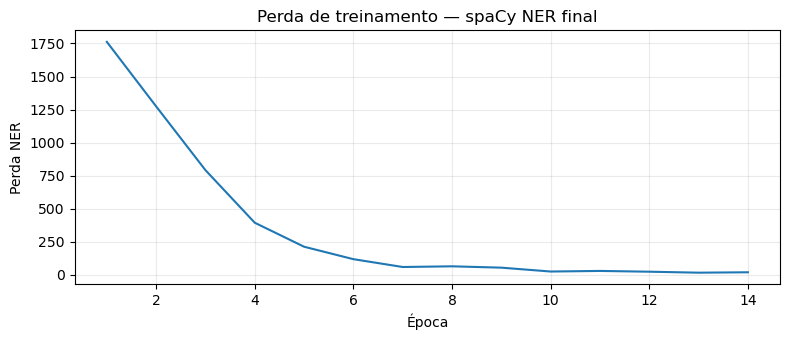

Configuração: {'dropout': 0.1, 'epochs': 14, 'seed': 42} | F1 teste humano: 0.929


In [14]:
best_spacy_config = {"dropout": float(spacy_validation.iloc[0]["dropout"]),
                     "epochs": int(round(spacy_validation.iloc[0]["Época_mediana"])),
                     "seed": SEED}
start = time.perf_counter()
spacy_model, spacy_history, _ = train_spacy_ner(
    development_records, best_spacy_config["epochs"],
    best_spacy_config["dropout"], best_spacy_config["seed"])
spacy_training_seconds = time.perf_counter()-start
spacy_path = MODELS_DIR / "spacy_ner"; spacy_model.to_disk(spacy_path)
spacy_size_mb = sum(p.stat().st_size for p in spacy_path.rglob("*") if p.is_file())/(1024**2)
spacy_history.to_csv(RESULTS_DIR / "historico_spacy_final.csv", index=False)
spacy_test_predictions = predict_spacy(spacy_model, test_records)
spacy_test_metrics = evaluate_entities(test_records, spacy_test_predictions)
spacy_ci = bootstrap_f1_ci(test_records, spacy_test_predictions)
test_predictions["spaCy NER"] = spacy_test_predictions
metrics_by_approach["spaCy NER"] = spacy_test_metrics
experiment_results["spaCy NER"] = result_row(
    "spaCy NER", "Modelo neural leve",
    f"epochs={best_spacy_config['epochs']}; dropout={best_spacy_config['dropout']:.2f}; seed={SEED}",
    spacy_test_metrics, spacy_ci, spacy_training_seconds, spacy_size_mb)
plt.figure(figsize=(8, 3.5)); plt.plot(spacy_history["epoch"], spacy_history["loss"])
plt.title("Perda de treinamento — spaCy NER final"); plt.xlabel("Época"); plt.ylabel("Perda NER")
plt.grid(alpha=.25); plt.tight_layout(); plt.show()
print("Configuração:", best_spacy_config,
      "| F1 teste humano:", f"{spacy_test_metrics['f1']:.3f}")

## 9. Desempenho por entidade

In [15]:
if not (metrics_by_approach.keys() == test_predictions.keys()
        == experiment_results.keys()):
    raise RuntimeError("Registros de abordagens dessincronizados; reexecute desde a baseline")
detailed_rows = []
for approach, metrics in metrics_by_approach.items():
    for label in LABELS:
        m = metrics["per_label"][label]
        detailed_rows.append({"Abordagem": approach, "TAG": label,
            "Precisão": m["precision"], "Recall": m["recall"], "F1": m["f1"],
            "Suporte": m["tp"]+m["fn"], "TP": m["tp"], "FP": m["fp"], "FN": m["fn"]})
per_label_table = pd.DataFrame(detailed_rows)
per_label_table.to_csv(RESULTS_DIR / "metricas_por_tag.csv", index=False)
display(per_label_table.style.format(precision=3))

,Abordagem,TAG,Precisão,Recall,F1,Suporte,TP,FP,FN
0,Regras,PRODUTO,0.920,0.455,0.609,101,46,4,55
1,Regras,MARCA,1.000,0.652,0.789,89,58,0,31
2,Regras,CONECTIVIDADE,1.000,0.817,0.899,71,58,0,13
3,Regras,COR,1.000,0.911,0.953,45,41,0,4
4,Regras,POTENCIA,1.000,1.000,1.000,22,22,0,0
5,CRF,PRODUTO,0.959,0.921,0.939,101,93,4,8
6,CRF,MARCA,0.988,0.921,0.953,89,82,1,7
7,CRF,CONECTIVIDADE,1.000,0.958,0.978,71,68,0,3
8,CRF,COR,0.977,0.933,0.955,45,42,1,3
9,CRF,POTENCIA,1.000,0.955,0.977,22,21,0,1


## 10. Matrizes de confusão por token

Todas as abordagens são projetadas no mesmo tokenizador de referência, pela maior
sobreposição de caracteres. A matriz ilustra confusões entre TAGs, mas não substitui
o F1 estrito por entidade e não representa perfeitamente erros de fronteira. Como
os spans da baseline podem cobrir apenas parte de uma palavra, sua matriz é uma
aproximação potencialmente otimista; a seleção final usa o F1 estrito.

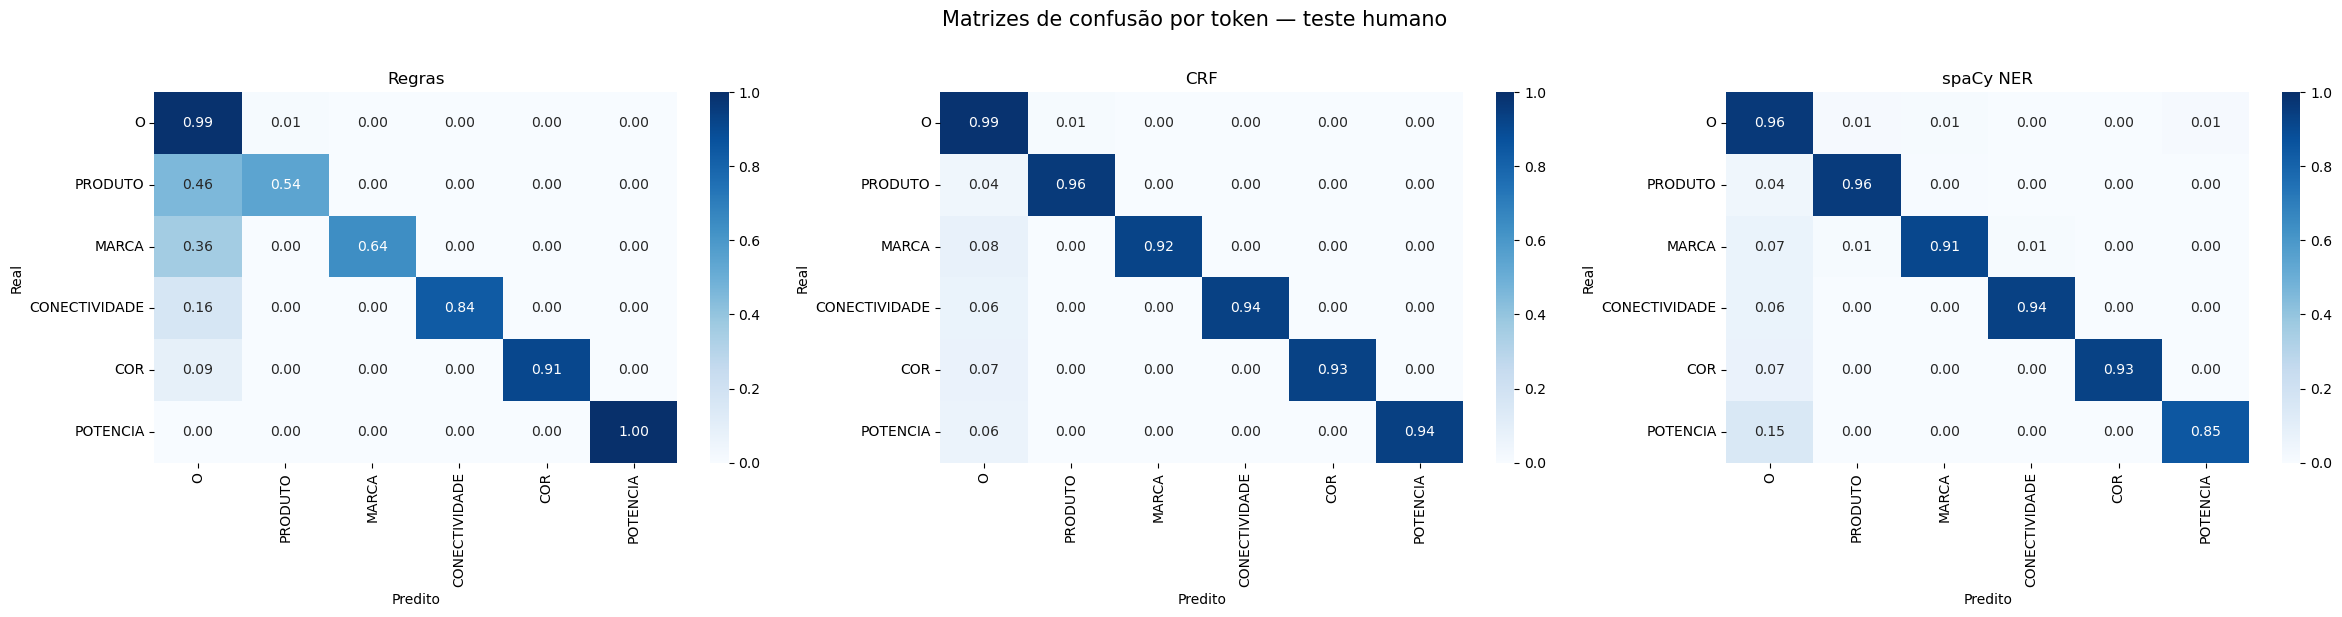

Figura salva em: /Users/pedrofonsecadeandrade/Desktop/Prioridades/2026/doutorado/disciplinas/Aula_Ciência_de_Dados/aula_04/Projeto_02/mt-lab-session-ner-starter/results/ner_models/matrizes_confusao.png


In [16]:
CONFUSION_LABELS = ["O", *LABELS]

def labels_per_reference_token(text, entities):
    tokens, labels, covered = tokenize_with_offsets(text), [], set()
    for _, token_start, token_end in tokens:
        overlaps = []
        for index, (start, end, label) in enumerate(entities):
            overlap = max(0, min(token_end, end)-max(token_start, start))
            if overlap: overlaps.append((overlap, index, label))
        if overlaps:
            _, index, label = max(overlaps, key=lambda item: (item[0], -item[1]))
            covered.add(index); labels.append(label)
        else: labels.append("O")
    return labels, len(entities) - len(covered)

gold_token_labels, gold_uncovered = [], 0
for row in test_records:
    labels, uncovered = labels_per_reference_token(row["text"], row["entities"])
    gold_token_labels.extend(labels); gold_uncovered += uncovered
if gold_uncovered:
    raise ValueError("Entidades de ouro sem token de referência; revise a tokenização")
n_approaches = len(test_predictions)
fig, axes = plt.subplots(1, n_approaches, figsize=(8*n_approaches, 6))
axes = np.atleast_1d(axes)
for axis, (approach, predictions) in zip(axes, test_predictions.items()):
    predicted_labels, uncovered_predictions = [], 0
    for row, entities in zip(test_records, predictions):
        labels, uncovered = labels_per_reference_token(row["text"], entities)
        predicted_labels.extend(labels); uncovered_predictions += uncovered
    if uncovered_predictions:
        print(f"Aviso — {approach}: {uncovered_predictions} entidades previstas não "
              "foram representadas na matriz por token; o F1 estrito não é afetado.")
    if len(predicted_labels) != len(gold_token_labels): raise ValueError("Projeção inconsistente")
    matrix = confusion_matrix(gold_token_labels, predicted_labels,
                              labels=CONFUSION_LABELS, normalize="true")
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CONFUSION_LABELS, yticklabels=CONFUSION_LABELS, ax=axis)
    axis.set(title=approach, xlabel="Predito", ylabel="Real")
plt.suptitle("Matrizes de confusão por token — teste humano", y=1.02, fontsize=15)
plt.tight_layout(); confusion_path = RESULTS_DIR / "matrizes_confusao.png"
plt.savefig(confusion_path, dpi=180, bbox_inches="tight"); plt.show()
print("Figura salva em:", confusion_path)

## 11. Análise de erros

- **TAG errada:** mesmos limites, rótulo diferente;
- **fronteira incorreta:** sobreposição com a mesma TAG, mas limites diferentes;
- **fronteira e TAG incorretas:** os dois problemas simultaneamente;
- **omissão:** entidade de ouro sem previsão sobreposta;
- **entidade espúria:** previsão que não foi associada a uma entidade de ouro.

Cada previsão errada é associada a no máximo uma entidade de ouro.

In [17]:
def error_examples(records, predictions, limit=10):
    rows = []
    for record, predicted_entities in zip(records, predictions):
        gold, predicted = set(map(tuple, record["entities"])), set(map(tuple, predicted_entities))
        if gold != predicted:
            rows.append({"Texto": record["text"],
                "Quantidade de erros": len(predicted-gold)+len(gold-predicted),
                "Falsos positivos": ", ".join(record["text"][s:e]+f"<{label}>"
                                               for s,e,label in sorted(predicted-gold)),
                "Omissões": ", ".join(record["text"][s:e]+f"<{label}>"
                                         for s,e,label in sorted(gold-predicted))})
    table = (pd.DataFrame(rows).sort_values(["Quantidade de erros", "Texto"],
             ascending=[False, True]) if rows else pd.DataFrame())
    return table.head(limit), len(rows)

def span_error_taxonomy(records, predictions):
    counts = Counter()
    for record, predicted_entities in zip(records, predictions):
        gold, predicted = set(map(tuple, record["entities"])), set(map(tuple, predicted_entities))
        remaining = sorted(predicted-gold)
        for g in sorted(gold-predicted):
            same_boundary = next((p for p in remaining if p[:2] == g[:2]), None)
            overlap_candidates = [
                p for p in remaining if min(p[1], g[1]) > max(p[0], g[0])
            ]
            overlap = max(
                overlap_candidates,
                key=lambda p: (
                    min(p[1], g[1]) - max(p[0], g[0]),
                    int(p[2] == g[2]), -p[0], -p[1], p[2],
                ),
                default=None,
            )
            match = same_boundary or overlap
            if same_boundary: counts["TAG errada"] += 1
            elif overlap and overlap[2] == g[2]: counts["Fronteira incorreta"] += 1
            elif overlap: counts["Fronteira e TAG incorretas"] += 1
            else: counts["Omissão"] += 1
            if match: remaining.remove(match)
        counts["Entidade espúria"] += len(remaining)
    return counts

for approach, predictions in test_predictions.items():
    examples, divergent = error_examples(test_records, predictions)
    print(f"{approach}: {divergent}/{len(test_records)} títulos com divergência")
    display(examples)
taxonomy_table = pd.DataFrame([{"Abordagem": approach,
    **span_error_taxonomy(test_records, predictions)}
    for approach, predictions in test_predictions.items()]).fillna(0)
taxonomy_table.to_csv(RESULTS_DIR / "taxonomia_erros.csv", index=False)
display(taxonomy_table)

Regras: 67/100 títulos com divergência


,Texto,Quantidade de erros,Falsos positivos,Omissões
24,Retro Mini System Vintage 250W CD/BT/USB/SD/FM...,4,,"Mini System<PRODUTO>, BT<CONECTIVIDADE>, SD<CO..."
54,Caixa Amplificada BlueTooth Multi-Uso NKS PK55...,3,fone<PRODUTO>,"Caixa Amplificada<PRODUTO>, SD<CONECTIVIDADE>"
38,Caixa de Som 3W Bluetooth GT Pure Gold Goldentec,3,,"GT<MARCA>, Gold<COR>, Goldentec<MARCA>"
10,Headphone Estéreo Hi-Fi GT Soul Colors - Azul ...,3,,"Headphone<PRODUTO>, GT<MARCA>, GT<MARCA>"
40,Headphone Estéreo Hi-Fi GT Soul Colors - Roxo ...,3,,"Headphone<PRODUTO>, GT<MARCA>, GT<MARCA>"
65,Kit Caixa JBL GO 2 Red + JBL Bar 2.1 Deep Bass,3,,"Caixa<PRODUTO>, Red<COR>, JBL<MARCA>"
23,Kit com 2 Headphone Bluetooth GT Follow Verde ...,3,,"Headphone<PRODUTO>, GT<MARCA>, GT<MARCA>"
50,"Mini System Portátil Novik Neo Impact 3, 1200W...",3,,"Mini System<PRODUTO>, BT<CONECTIVIDADE>, SD<CO..."
43,"Suporte Para Caixa de Som Amplificada, 150W/40...",3,Caixa de Som<PRODUTO>,"Suporte<PRODUTO>, GT<MARCA>"
16,Suporte Universal para Projetor 3 em 1 | GT,3,Projetor<PRODUTO>,"Suporte<PRODUTO>, GT<MARCA>"


CRF: 23/100 títulos com divergência


,Texto,Quantidade de erros,Falsos positivos,Omissões
10,Headset Gamer Sony Pulse 3D para PS5,2,Pulse<MARCA>,Sony<MARCA>
5,Mini System Sony V21D com tecnologia Bluetooth...,2,Chain<COR>,Sony<MARCA>
7,Retro Mini System Vintage 250W CD/BT/USB/SD/FM...,2,Retro Mini System<PRODUTO>,Mini System<PRODUTO>
20,SoundBar LG SL5Y 2.1 Canais Subwoofer Wireless...,2,,"SoundBar<PRODUTO>, Óptico<CONECTIVIDADE>"
19,"iPod touch 6 Apple, 64GB,iOS 8, Chip A8 , Wi-F...",2,,"Wi-Fi<CONECTIVIDADE>, Silver<COR>"
16,Caixa Amplificada BlueTooth Multi-Uso NKS PK55...,1,,NKS<MARCA>
11,Caixa De Som Bluetooh 5w Preta - Geonav Aercx01bk,1,,Geonav<MARCA>
12,Caixa de Som 3W Bluetooth GT Pure Gold Goldentec,1,,Gold<COR>
8,Caixa de Som Retrô Bluetooth Speaker Presley 8...,1,Speaker<PRODUTO>,
17,Caixa de Som Speaker TCL Bluetooth Extra Bass ...,1,,TCL<MARCA>


spaCy NER: 31/100 títulos com divergência


,Texto,Quantidade de erros,Falsos positivos,Omissões
29,Kit Caixa JBL GO 2 Red + JBL Bar 2.1 Deep Bass,3,Caixa JBL<PRODUTO>,"Caixa<PRODUTO>, JBL<MARCA>"
16,Toca-Disco ObaWave Conversor de Vinil Obabox -...,3,"Toca-<PRODUTO>, Conversor de Vinil<PRODUTO>",Toca-Disco<PRODUTO>
25,Amplificador Frahm Profissional GR 5000,2,Amplificador<MARCA>,Amplificador<PRODUTO>
11,Caixa De Som Bluetooh 5w Preta - Geonav Aercx01bk,2,,"5w<POTENCIA>, Geonav<MARCA>"
24,Caixa de Som Speaker TCL Bluetooth Extra Bass ...,2,TCL<CONECTIVIDADE>,TCL<MARCA>
8,Headset Gamer Sony Pulse 3D para PS5,2,Pulse<MARCA>,Sony<MARCA>
22,"Mini System Portátil Novik Neo Impact 3, 1200W...",2,"3, 1200W<POTENCIA>",1200W<POTENCIA>
5,Mini System Sony V21D com tecnologia Bluetooth...,2,Chain<MARCA>,Sony<MARCA>
6,Retro Mini System Vintage 250W CD/BT/USB/SD/FM...,2,,"Mini System<PRODUTO>, 250W<POTENCIA>"
28,SoundBar LG SL5Y 2.1 Canais Subwoofer Wireless...,2,,"SoundBar<PRODUTO>, Óptico<CONECTIVIDADE>"


,Abordagem,Omissão,Entidade espúria,Fronteira incorreta,TAG errada
0,Regras,103,4,0.0,0.0
1,CRF,21,5,1.0,0.0
2,spaCy NER,22,14,3.0,2.0


## 12. Salvamento e rastreabilidade

In [18]:
def save_predictions(path, records, predictions):
    with path.open("w", encoding="utf-8") as destination:
        for record, entities in zip(records, predictions):
            destination.write(json.dumps({"text": record["text"], "entities": entities},
                                         ensure_ascii=False)+"\n")

save_predictions(RESULTS_DIR/"predicoes_regras.jsonl", test_records, baseline_predictions)
save_predictions(RESULTS_DIR/"predicoes_crf.jsonl", test_records, crf_test_predictions)
save_predictions(RESULTS_DIR/"predicoes_spacy.jsonl", test_records, spacy_test_predictions)
run_metadata = {"executed_at_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED, "spacy_seeds": list(SPACY_SEEDS), "validation_size": VALIDATION_SIZE,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "dataset_sizes": {"development": len(development_records), "train": len(train_records),
                      "validation": len(validation_records), "human_test": len(test_records)},
    "versions": PACKAGE_VERSIONS, "selected_crf": best_crf_config,
    "selected_spacy": best_spacy_config,
    "search_space": {
        "crf_c_grid": list(CRF_C_GRID), "crf_base_params": CRF_BASE_PARAMS,
        "spacy_dropouts": list(SPACY_DROPOUTS),
        "spacy_max_epochs": SPACY_MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "spacy_batch_schedule": list(SPACY_BATCH_SCHEDULE),
    }}
(RESULTS_DIR/"metadados_execucao.json").write_text(
    json.dumps(run_metadata, ensure_ascii=False, indent=2)+"\n", encoding="utf-8")
final_metrics = {name: {key: value for key, value in row.items()
                        if key not in {"Tempo treino (s)", "Tamanho (MB)"}}
                 for name, row in experiment_results.items()}
(RESULTS_DIR/"metricas_finais.json").write_text(
    json.dumps(final_metrics, ensure_ascii=False, indent=2)+"\n", encoding="utf-8")
print("Artefatos salvos em:", RESULTS_DIR)

Artefatos salvos em: /Users/pedrofonsecadeandrade/Desktop/Prioridades/2026/doutorado/disciplinas/Aula_Ciência_de_Dados/aula_04/Projeto_02/mt-lab-session-ner-starter/results/ner_models


## 13. Conclusão e tabela final

A seleção usa prioritariamente o F1 micro estrito no teste humano, considerando
também IC95%, desempenho por TAG, erros, tempo e tamanho. O IC do spaCy é
condicional à semente final e não incorpora toda a variância de inicialização.
Com apenas 100 exemplos de teste, a conclusão usa também um bootstrap pareado da
diferença entre as duas melhores abordagens.

In [19]:
comparison_table = (pd.DataFrame(experiment_results.values())
    .sort_values(["F1 micro", "Recall", "Abordagem"],
                 ascending=[False, False, True]).reset_index(drop=True))
comparison_table.to_csv(RESULTS_DIR/"comparacao_modelos.csv", index=False)
best = comparison_table.iloc[0]
weakest = (per_label_table[per_label_table["Abordagem"] == best["Abordagem"]]
           .sort_values(["F1", "Suporte"], ascending=[True, False]).iloc[0])
runner_up = comparison_table.iloc[1]
difference_ci = paired_bootstrap_f1_difference(
    test_records, test_predictions[best["Abordagem"]],
    test_predictions[runner_up["Abordagem"]])
if difference_ci[0] > 0:
    conclusion = "diferença positiva sustentada pelo bootstrap pareado"
else:
    conclusion = "maior F1 observado, mas diferença inconclusiva a 95%"
print(f"{best['Abordagem']}: {conclusion} (F1={best['F1 micro']:.3f}; "
      f"IC95% [{best['IC95% inferior']:.3f}, {best['IC95% superior']:.3f}]; "
      f"IC95% da diferença vs. {runner_up['Abordagem']} "
      f"[{difference_ci[0]:.3f}, {difference_ci[1]:.3f}]).")
print(f"TAG mais difícil: {weakest['TAG']} (F1={weakest['F1']:.3f}).")
display(comparison_table.style.format({"Precisão": "{:.3f}", "Recall": "{:.3f}",
    "F1 micro": "{:.3f}", "IC95% inferior": "{:.3f}", "IC95% superior": "{:.3f}",
    "F1 macro": "{:.3f}", "Tempo treino (s)": "{:.2f}", "Tamanho (MB)": "{:.2f}"},
    na_rep="—").highlight_max(subset=["F1 micro"], color="#dcfce7"))

CRF: diferença positiva sustentada pelo bootstrap pareado (F1=0.956; IC95% [0.940, 0.972]; IC95% da diferença vs. spaCy NER [0.008, 0.047]).
TAG mais difícil: PRODUTO (F1=0.939).


,Abordagem,Tipo,Configuração,Precisão,Recall,F1 micro,IC95% inferior,IC95% superior,F1 macro,TP,FP,FN,Tempo treino (s),Tamanho (MB)
0,CRF,Modelo estatístico sequencial,c1=0.01; c2=0.01,0.981,0.933,0.956,0.940,0.972,0.961,306,6,22,0.15,0.18
1,spaCy NER,Modelo neural leve,epochs=14; dropout=0.10; seed=42,0.941,0.918,0.929,0.903,0.952,0.912,301,19,27,7.14,3.68
2,Regras,Baseline não treinada,listas + expressões regulares,0.983,0.686,0.808,0.768,0.843,0.850,225,4,103,—,—


## Conclusão

No teste humano com 100 títulos, o **CRF** apresentou o melhor desempenho observado: **F1 micro de 0,956**, precisão de **0,981** e recall de **0,933**. Também foi o modelo mais consistente entre as TAGs, com F1 acima de 0,93 em todas elas.

O **spaCy NER leve** teve bom resultado (**F1 = 0,929**), mas com mais falsos positivos e maior dificuldade para identificar `POTENCIA` (F1 = 0,791).

A baseline por **regras** obteve alta precisão (**0,983**), porém recall menor (**0,686**), pois deixou de identificar muitas entidades, especialmente `PRODUTO`.

Assim, o **CRF foi selecionado** como a melhor abordagem para extrair atributos de títulos de produtos desta base.